# Fragment-Length Frequency

In [2]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Number of Data Points in Dataset = 13835737


/var/folders/kv/xnj6pn757lxdlvnf8_vntwyc0000gn/T/ipykernel_23803/2742800419.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


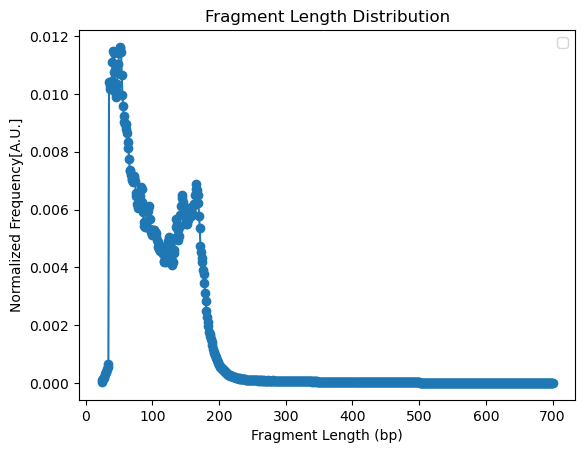

In [3]:
fragment_lengths = {}
with gzip.open("query.bed.gz", "rt") as f:
    for line in f:
        chromosome, start, end, *rest = line.split()
        start, end = int(start), int(end)
        length = end - start
        if length in fragment_lengths:
            fragment_lengths[length] += 1
        else:
            fragment_lengths[length] = 1
lengths = sorted(fragment_lengths.keys())
counts = [fragment_lengths[length] for length in lengths]
sum_of_counts = sum(counts)
print("Number of Data Points in Dataset =", end= ' ')
print(sum_of_counts)
normalized_fragment_frequencies = {}
for length in fragment_lengths.keys():
    normalized_fragment_frequencies[length] = fragment_lengths[length] / sum_of_counts
normalized_freq = np.array([normalized_fragment_frequencies[l] for l in lengths])
plt.plot(lengths, normalized_freq, marker='o')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency[A.U.]")
plt.title("Fragment Length Distribution")
plt.legend()
plt.show()

# Rescaling (By Sub-Sampling)
From 13,835,737 data points available in original query dataset, let us sub-sample, say N data points

In [4]:
reference = pd.read_csv("reference.hist", sep = "\t")
print(reference.columns)
print(reference)
reference.columns = ['length', 'normalized']
print(reference)

Index(['24', '1.3434701388555048e-05'], dtype='object')
      24  1.3434701388555048e-05
0     25                0.000063
1     26                0.000092
2     27                0.000117
3     28                0.000136
4     29                0.000163
..   ...                     ...
671  696                0.000010
672  697                0.000010
673  698                0.000010
674  699                0.000010
675  700                0.000010

[676 rows x 2 columns]
     length  normalized
0        25    0.000063
1        26    0.000092
2        27    0.000117
3        28    0.000136
4        29    0.000163
..      ...         ...
671     696    0.000010
672     697    0.000010
673     698    0.000010
674     699    0.000010
675     700    0.000010

[676 rows x 2 columns]


From observing normalized frequencies of this reference file and size of our large query file (>13 million data points), I set N = 1,000,000 (1 million), this value of N can be experimented with too !

999637
Nearly 1 million reads were sub-sampled


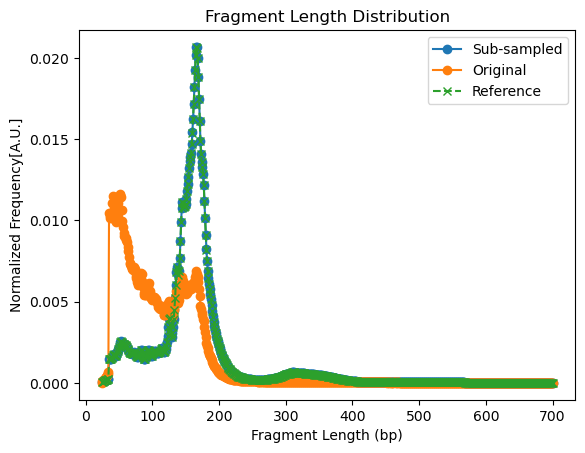

In [5]:
N = 1000000
reference['target'] = reference['normalized'] * N
reference['target'] = reference['target'].astype(int)
target = dict(zip(reference['length'], reference['target']))
sub_sampled_lengths = []
taken = {}
with gzip.open("query.bed.gz", "rt") as f:
    for line in f:
        chromosome, start, end, *rest = line.split()
        start, end = int(start), int(end)
        length = end - start
        if length in target:
            if length in taken:
                if taken[length] < target[length]:
                    taken[length] += 1
                    sub_sampled_lengths.append(length)
            else:
                taken[length] = 1
                sub_sampled_lengths.append(length)
                

N_sub_sampled = len(sub_sampled_lengths)
print(N_sub_sampled)
print("Nearly 1 million reads were sub-sampled")
sub_sampled_lengths_2 = sorted(taken.keys())
sub_sampled_normalized_counts = [(taken[length]/ (N_sub_sampled)) for length in sub_sampled_lengths_2]
plt.plot(sub_sampled_lengths_2, sub_sampled_normalized_counts, marker='o', label = 'Sub-sampled')
plt.plot(lengths, normalized_freq, marker='o', label = 'Original')
plt.plot(reference['length'], reference['normalized'], marker='x', label='Reference', linestyle='--')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency[A.U.]")
plt.title("Fragment Length Distribution")
plt.legend()
plt.show()

